# 01 — Correct BCHH instrument response

This is the **canonical production notebook** for the Falcon 9 Fireball analysis.

It performs only the steps required to create the authoritative response-corrected
BCHH waveform and metadata products:

1. load the event-epoch StationXML;
2. read and cache the raw BCHH waveform window;
3. read the original Antelope calibration table;
4. rescale the three infraBSU responses to the empirical event-epoch calibration;
5. remove the complete instrument response;
6. save corrected miniSEED, Pickle, StationXML, summary, and provenance products;
7. generate a focused diagnostic waveform plot.

The extended NRL, stage-response, and alternative-calibration investigations have
been moved to `S01_validate_infrabsu_response.ipynb`.


## 1. Imports and configuration


In [1]:

from __future__ import annotations

import copy
import json
from pathlib import Path
from typing import Iterable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from obspy import Stream, UTCDateTime, read, read_inventory
from obspy.core.inventory import Inventory

plt.rcParams.update({"figure.dpi": 120, "font.size": 9})


In [ ]:
import sys
from pathlib import Path

project_root = Path.cwd().resolve()
if project_root.name == "notebooks":
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from modules import project_config as config

In [ ]:

OVERWRITE_RAW_MSEED = False

READ_START = config.EXPLOSION_TIME - config.PRETRIGGER_WINDOW
READ_END = config.EXPLOSION_TIME + config.POSTTRIGGER_WINDOW

PRESSURE_BASELINE_START = config.EXPLOSION_TIME - 20.0
PRESSURE_BASELINE_END = config.EXPLOSION_TIME - 2.0

INFRASOUND_PRE_FILT = (0.02, 0.05, 80.0, 100.0)
SEISMIC_PRE_FILT = (0.02, 0.05, 80.0, 100.0)
RESPONSE_WATER_LEVEL_DB = 60.0

BCHH_NETWORK = "1R"
BCHH_STATION = "BCHH"
BCHH_LOCATION = "10"

WAVEFORM_TO_XML_CHANNEL = {
    "HD1": "DD1",
    "HD2": "DD2",
    "HD3": "DD3",
    "HHE": "DHE",
    "HHN": "DHN",
    "HHZ": "DHZ",
}
XML_TO_WAVEFORM_CHANNEL = {v: k for k, v in WAVEFORM_TO_XML_CHANNEL.items()}
CHANNEL_ORDER = list(WAVEFORM_TO_XML_CHANNEL)

for required_path, label in [
    (config.MINISEED_DIR, "raw miniSEED directory"),
    (config.STATIONXML_FILE, "event StationXML"),
    (config.CSS_CALIBRATION_FILE, "Antelope calibration table"),
]:
    if not required_path.exists():
        raise FileNotFoundError(f"{label} not found: {required_path}")


## 2. Load the event-epoch inventory

Coordinates, channel orientations, sample rates, and nominal response shapes are
taken from the active StationXML epoch. The original event inventory and a flattened
channel metadata table are saved for provenance.


In [5]:
def load_event_inventory(
    stationxml_file: Path,
    *,
    network: str,
    station: str,
    location: str,
    starttime: UTCDateTime,
    endtime: UTCDateTime,
) -> Inventory:
    """Load the StationXML and retain only active BCHH channel epochs."""
    if not stationxml_file.exists():
        raise FileNotFoundError(stationxml_file)

    inventory = read_inventory(str(stationxml_file))
    selected = inventory.select(
        network=network,
        station=station,
        location=location,
        time=starttime,
    )

    # Retain only channels that overlap the requested time interval.
    keep = set(WAVEFORM_TO_XML_CHANNEL.values())
    selected = copy.deepcopy(selected)
    for net in selected:
        for sta in net:
            sta.channels = [
                cha for cha in sta.channels
                if cha.code in keep
                and (cha.start_date is None or cha.start_date <= endtime)
                and (cha.end_date is None or cha.end_date >= starttime)
            ]

    if not any(sta.channels for net in selected for sta in net):
        raise ValueError("No active BCHH response channels found in StationXML")

    return selected


def inventory_channels_to_dataframe(inventory: Inventory) -> pd.DataFrame:
    """Flatten channel coordinates and response sensitivities into a table."""
    rows = []
    for net in inventory:
        for sta in net:
            for cha in sta:
                response = cha.response
                sensitivity = getattr(response, "instrument_sensitivity", None)
                rows.append({
                    "seed_id": f"{net.code}.{sta.code}.{cha.location_code}.{cha.code}",
                    "network": net.code,
                    "station": sta.code,
                    "location": cha.location_code,
                    "channel": cha.code,
                    "waveform_channel": XML_TO_WAVEFORM_CHANNEL.get(cha.code),
                    "latitude": float(cha.latitude),
                    "longitude": float(cha.longitude),
                    "elevation_m": float(cha.elevation),
                    "depth_m": float(cha.depth),
                    "azimuth_deg": None if cha.azimuth is None else float(cha.azimuth),
                    "dip_deg": None if cha.dip is None else float(cha.dip),
                    "sample_rate_hz": None if cha.sample_rate is None else float(cha.sample_rate),
                    "sensitivity": None if sensitivity is None else float(sensitivity.value),
                    "sensitivity_frequency_hz": None if sensitivity is None else float(sensitivity.frequency),
                    "input_units": None if sensitivity is None else str(sensitivity.input_units),
                    "output_units": None if sensitivity is None else str(sensitivity.output_units),
                })
    return pd.DataFrame(rows).sort_values("channel").reset_index(drop=True)


inventory_event = load_event_inventory(
    config.STATIONXML_FILE,
    network=BCHH_NETWORK,
    station=BCHH_STATION,
    location=BCHH_LOCATION,
    starttime=READ_START,
    endtime=READ_END,
)

channel_metadata_df = inventory_channels_to_dataframe(inventory_event)
display(channel_metadata_df)

print(config.EVENT_STATIONXML_COPY)
inventory_event.write(str(config.EVENT_STATIONXML_COPY), format="STATIONXML", validate=True)
channel_metadata_df.to_csv(config.CHANNEL_METADATA_CSV, index=False)
print(f"Saved event inventory: {config.EVENT_STATIONXML_COPY}")
print(f"Saved channel coordinates: {config.CHANNEL_METADATA_CSV}")


,seed_id,network,station,location,channel,waveform_channel,latitude,longitude,elevation_m,depth_m,azimuth_deg,dip_deg,sample_rate_hz,sensitivity,sensitivity_frequency_hz,input_units,output_units
0,1R.BCHH.10.DD1,1R,BCHH,10,DD1,HD1,28.574222,-80.572417,0.0,0.0,0.0,0.0,250.0,1.840000e+01,1.0,Pa,count
1,1R.BCHH.10.DD2,1R,BCHH,10,DD2,HD2,28.573881,-80.572296,0.0,0.0,90.0,0.0,250.0,1.840000e+01,1.0,Pa,count
2,1R.BCHH.10.DD3,1R,BCHH,10,DD3,HD3,28.574006,-80.572560,0.0,0.0,0.0,0.0,250.0,1.840000e+01,1.0,Pa,count
3,1R.BCHH.10.DHE,1R,BCHH,10,DHE,HHE,28.574017,-80.572376,0.0,0.0,90.0,0.0,250.0,3.017200e+08,1.0,m/s,count
4,1R.BCHH.10.DHN,1R,BCHH,10,DHN,HHN,28.574017,-80.572376,0.0,0.0,0.0,0.0,250.0,3.017200e+08,1.0,m/s,count
5,1R.BCHH.10.DHZ,1R,BCHH,10,DHZ,HHZ,28.574017,-80.572376,0.0,0.0,0.0,-90.0,250.0,3.017200e+08,1.0,m/s,count


/Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/outputs/01_bchh_event_inventory_original.xml
Saved event inventory: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/outputs/01_bchh_event_inventory_original.xml
Saved channel coordinates: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/outputs/01_bchh_channel_metadata.csv


## 3. Read and cache the raw BCHH waveform


In [7]:
def read_bchh_stream(
    miniseed_dir: Path,
    cache_file: Path,
    starttime: UTCDateTime,
    endtime: UTCDateTime,
    *,
    overwrite_cache: bool = False,
) -> Stream:
    """Read BCHH day files, trim, merge, and optionally cache the raw counts."""
    if cache_file.exists() and not overwrite_cache:
        st = read(str(cache_file))
        st.trim(starttime, endtime, pad=False)
        return st

    patterns = ["*.20160901T000000", "*.mseed", "*.msd", "*.miniseed"]
    files = []
    for pattern in patterns:
        files.extend(miniseed_dir.glob(pattern))
    files = sorted(set(files))

    if not files:
        raise FileNotFoundError(f"No miniSEED files found in {miniseed_dir}")

    st = Stream()
    for filename in files:
        st += read(str(filename))

    st.trim(starttime, endtime, pad=False)
    st.merge(method=1, fill_value="interpolate")
    st.sort(keys=["station", "channel"])
    st.write(str(cache_file), format="MSEED")
    return st


st_raw = read_bchh_stream(
    config.MINISEED_DIR,
    config.RAW_MSEED,
    READ_START,
    READ_END,
    overwrite_cache=OVERWRITE_RAW_MSEED,
)

print(st_raw)
for tr in st_raw:
    print(tr.id, tr.stats.starttime, tr.stats.endtime, tr.stats.sampling_rate, tr.stats.npts)


9 Trace(s) in Stream:
FL.BCHH.00.HD1 | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
FL.BCHH.10.HD1 | 2016-09-01T13:07:00.000000Z - 2016-09-01T13:10:00.000000Z | 250.0 Hz, 45001 samples
FL.BCHH.00.HD2 | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
FL.BCHH.10.HD2 | 2016-09-01T13:07:00.000000Z - 2016-09-01T13:10:00.000000Z | 250.0 Hz, 45001 samples
FL.BCHH.00.HD3 | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
FL.BCHH.10.HD3 | 2016-09-01T13:07:00.000000Z - 2016-09-01T13:10:00.000000Z | 250.0 Hz, 45001 samples
FL.BCHH.00.HHE | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
FL.BCHH.00.HHN | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
FL.BCHH.00.HHZ | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
FL.BCHH.00.HD1 2016-09-01T13:04:12.080000Z 2016-09-01T13:37:12.

## 4. Read the event-epoch Antelope pressure calibrations

For pressure channels, Antelope `calib` is interpreted as the multiplier from raw
counts to pressure in Pa. The reciprocal is the empirical overall sensitivity in
count/Pa.


In [8]:
def read_css_calibration_table(path: Path | str) -> pd.DataFrame:
    """Read the fields needed from an Antelope CSS3.0 calibration table.

    The instrument and recorder descriptions contain spaces, so fields are
    extracted from both ends of each whitespace-delimited row:
      sta, chan, time, endtime, ..., calib, calper, tshift, units, lddate
    """
    rows = []
    path = Path(path)
    for line_number, line in enumerate(path.read_text().splitlines(), start=1):
        if not line.strip() or line.lstrip().startswith("#"):
            continue
        fields = line.split()
        if len(fields) < 10:
            raise ValueError(f"Malformed calibration row {line_number}: {line}")
        rows.append({
            "station": fields[0],
            "css_channel": fields[1],
            "start_epoch": float(fields[2]),
            "end_epoch": float(fields[3]),
            "calib": float(fields[-5]),
            "calper": float(fields[-4]),
            "tshift": float(fields[-3]),
            "units": fields[-2],
            "lddate_epoch": float(fields[-1]),
            "line_number": line_number,
            "raw_line": line,
        })
    return pd.DataFrame(rows)


def active_css_calibrations(
    table: pd.DataFrame,
    *,
    station: str,
    event_time: UTCDateTime,
    waveform_channels: Iterable[str],
) -> pd.DataFrame:
    """Select exactly one active calibration row for each waveform channel."""
    event_epoch = float(event_time.timestamp)
    selected_rows = []

    for waveform_channel in waveform_channels:
        css_channel = f"{waveform_channel}_00"
        matches = table[
            (table["station"] == station)
            & (table["css_channel"] == css_channel)
            & (table["start_epoch"] <= event_epoch)
            & (table["end_epoch"] >= event_epoch)
        ]
        if len(matches) != 1:
            raise ValueError(
                f"Expected one active calibration for {station}.{css_channel} "
                f"at {event_time}; found {len(matches)}"
            )
        selected_rows.append(matches.iloc[0])

    result = pd.DataFrame(selected_rows).reset_index(drop=True)
    result["waveform_channel"] = result["css_channel"].str.replace(
        "_00", "", regex=False
    )
    result["count_per_unit"] = 1.0 / result["calib"]
    return result


css_calibration_df = read_css_calibration_table(config.CSS_CALIBRATION_FILE)
active_pressure_calibration_df = active_css_calibrations(
    css_calibration_df,
    station=BCHH_STATION,
    event_time=EXPLOSION_TIME,
    waveform_channels=["HD1", "HD2", "HD3"],
)

print("Active empirical pressure calibrations:")
display(
    active_pressure_calibration_df[
        [
            "waveform_channel",
            "start_epoch",
            "end_epoch",
            "calib",
            "units",
            "count_per_unit",
        ]
    ]
)

pressure_calib_pa_per_count = dict(
    zip(
        active_pressure_calibration_df["waveform_channel"],
        active_pressure_calibration_df["calib"],
    )
)

for channel, value in pressure_calib_pa_per_count.items():
    print(f"{channel}: {value:g} Pa/count ({1.0/value:g} count/Pa)")


active_pressure_calibration_df.to_csv(config.ACTIVE_CALIBRATION_CSV, index=False)
print(f"Saved active pressure calibrations: {config.ACTIVE_CALIBRATION_CSV}")


Active empirical pressure calibrations:


,waveform_channel,start_epoch,end_epoch,calib,units,count_per_unit
0,HD1,1.463530e+09,1.473379e+09,0.1234,Pa,8.103728
1,HD2,1.463530e+09,1.473379e+09,1.4499,Pa,0.689703
2,HD3,1.463530e+09,1.473379e+09,0.1000,Pa,10.000000


HD1: 0.1234 Pa/count (8.10373 count/Pa)
HD2: 1.4499 Pa/count (0.689703 count/Pa)
HD3: 0.1 Pa/count (10 count/Pa)
Saved active pressure calibrations: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/outputs/01_bchh_active_antelope_calibration.csv


## 5. Trace-ID and baseline helpers


In [9]:
def remap_trace_to_inventory_id(
    trace,
    *,
    inventory_network: str,
    inventory_station: str,
    inventory_location: str,
):
    """Copy a waveform trace and temporarily assign its StationXML NSLC code."""
    out = trace.copy()
    waveform_channel = out.stats.channel.upper()
    if waveform_channel not in WAVEFORM_TO_XML_CHANNEL:
        raise ValueError(f"No StationXML mapping defined for {trace.id}")

    original_codes = {
        "network": out.stats.network,
        "station": out.stats.station,
        "location": out.stats.location,
        "channel": out.stats.channel,
    }
    out.stats.network = inventory_network
    out.stats.station = inventory_station
    out.stats.location = inventory_location
    out.stats.channel = WAVEFORM_TO_XML_CHANNEL[waveform_channel]
    return out, original_codes


def restore_trace_id(trace, original_codes: dict) -> None:
    for key, value in original_codes.items():
        setattr(trace.stats, key, value)


def median_in_window(trace, starttime: UTCDateTime, endtime: UTCDateTime) -> float:
    window = trace.copy().trim(starttime, endtime, pad=False)
    if window.stats.npts == 0:
        raise ValueError(f"No samples in baseline window for {trace.id}")
    return float(np.nanmedian(np.asarray(window.data, dtype=np.float64)))


## 6. Build the empirically calibrated inventory and correct the waveforms

The nominal infraBSU response shape is retained, but the amplitude of the first
physical response stage is rescaled so that the complete response matches each
channel's empirical Antelope calibration. The full response is then removed from
all six channels.

- infrasound output: Pa;
- seismic output: ground velocity in m/s.


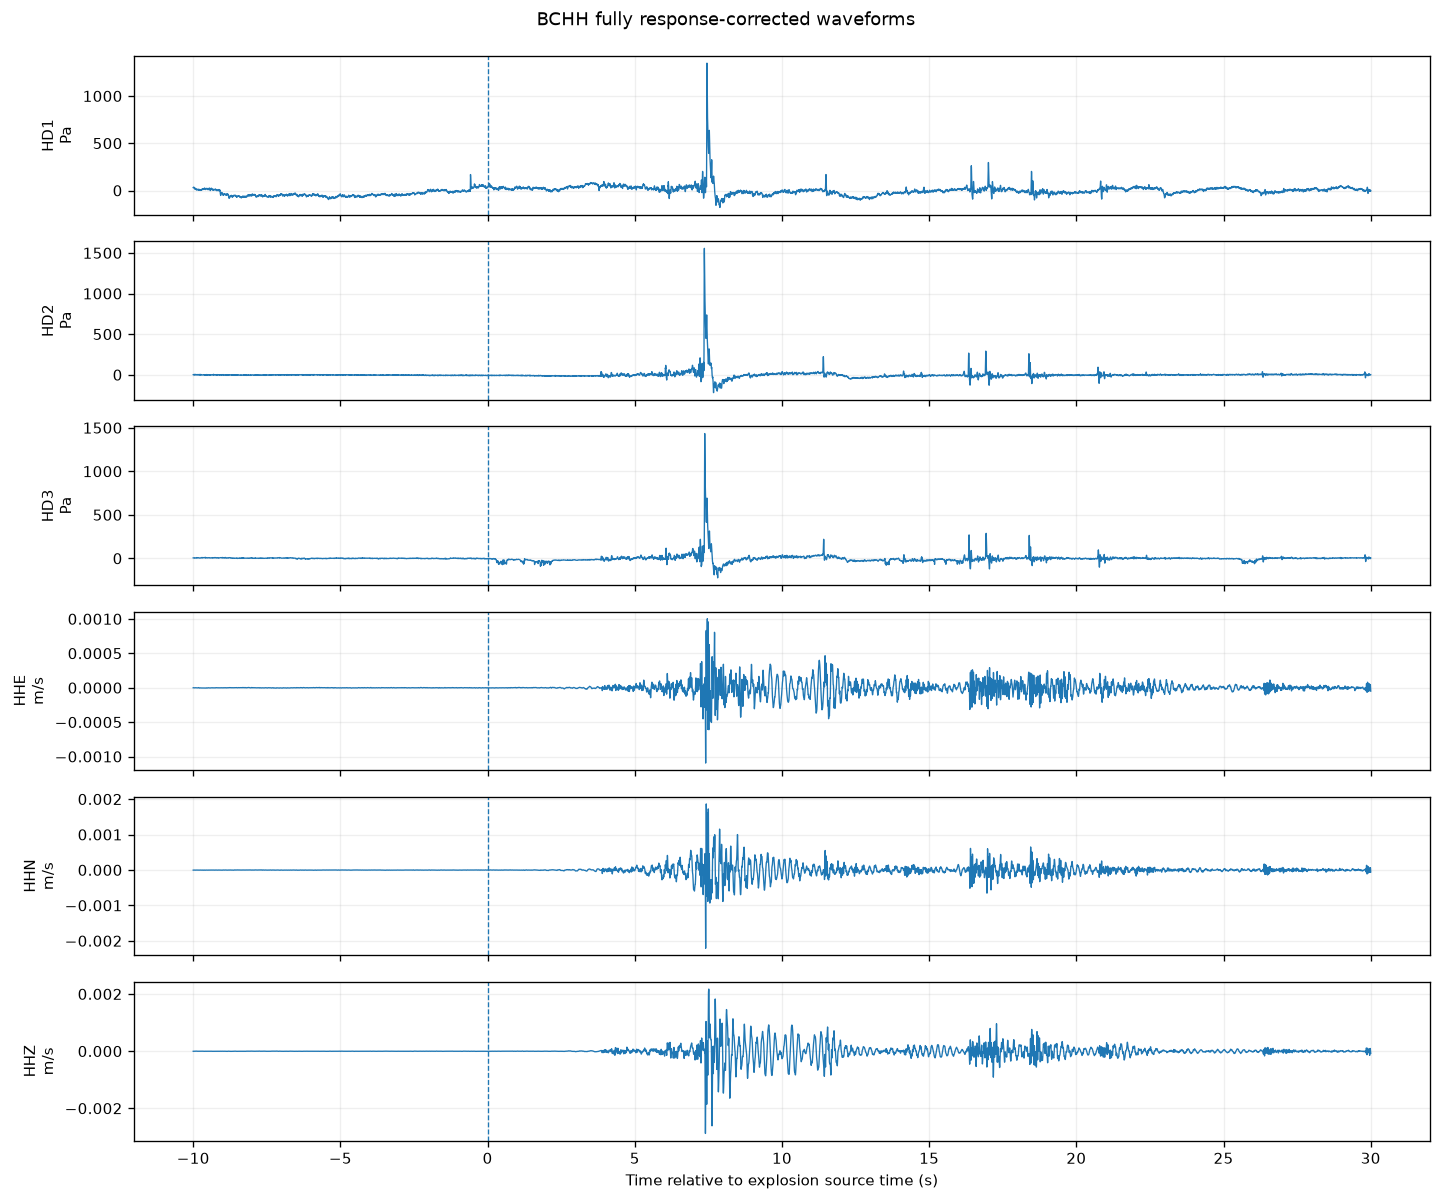

Final corrected inventory:
  /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/outputs/01_BCHH_20160901_empirically_calibrated.xml
Final corrected streams:
  /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/outputs/01_BCHH_20160901_response_corrected.mseed
  /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/outputs/01_BCHH_20160901_response_corrected.pkl
Diagnostics:
  /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/outputs/01_BCHH_20160901_correction_summary.csv


,waveform_id,inventory_id,output_units,baseline_removed_counts,pre_filt_hz,water_level_db,peak_absolute,minimum,maximum,rms
0,FL.BCHH.00.HD1,1R.BCHH.10.DD1,Pa,-367519.0,"(0.02, 0.05, 80.0, 100.0)",60.0,1349.141452,-253.017930,1349.141452,33.066901
1,FL.BCHH.10.HD1,1R.BCHH.10.DD1,Pa,-367970.0,"(0.02, 0.05, 80.0, 100.0)",60.0,1343.682120,-184.481699,1343.682120,48.501311
2,FL.BCHH.00.HD2,1R.BCHH.10.DD2,Pa,1921.0,"(0.02, 0.05, 80.0, 100.0)",60.0,1557.411627,-219.103736,1557.411627,7.850681
3,FL.BCHH.10.HD2,1R.BCHH.10.DD2,Pa,1922.0,"(0.02, 0.05, 80.0, 100.0)",60.0,1557.519849,-218.974885,1557.519849,24.714370
4,FL.BCHH.00.HD3,1R.BCHH.10.DD3,Pa,23215.0,"(0.02, 0.05, 80.0, 100.0)",60.0,1434.860925,-222.554264,1434.860925,13.326245
5,FL.BCHH.10.HD3,1R.BCHH.10.DD3,Pa,23218.0,"(0.02, 0.05, 80.0, 100.0)",60.0,1435.047033,-222.393763,1435.047033,26.587385
6,FL.BCHH.00.HHE,1R.BCHH.10.DHE,m/s,NaN,"(0.02, 0.05, 80.0, 100.0)",60.0,0.001094,-0.001094,0.001004,0.000013
7,FL.BCHH.00.HHN,1R.BCHH.10.DHN,m/s,NaN,"(0.02, 0.05, 80.0, 100.0)",60.0,0.002207,-0.002207,0.001867,0.000022
8,FL.BCHH.00.HHZ,1R.BCHH.10.DHZ,m/s,NaN,"(0.02, 0.05, 80.0, 100.0)",60.0,0.002876,-0.002876,0.002173,0.000033


In [13]:
def _single_selected_channel(
    inventory: Inventory,
    *,
    network: str,
    station: str,
    location: str,
    channel: str,
    time: UTCDateTime,
):
    """Return exactly one selected Channel object."""
    selected = inventory.select(
        network=network,
        station=station,
        location=location,
        channel=channel,
        time=time,
    )
    channels = [
        cha
        for net in selected
        for sta in net
        for cha in sta
    ]
    if len(channels) != 1:
        raise ValueError(
            f"Expected one channel for "
            f"{network}.{station}.{location}.{channel}; found {len(channels)}"
        )
    return channels[0]


def build_empirically_calibrated_inventory(
    inventory: Inventory,
    *,
    network: str,
    station: str,
    location: str,
    waveform_to_xml_channel: dict[str, str],
    pressure_calib_pa_per_count: dict[str, float],
    time: UTCDateTime,
) -> Inventory:
    """Return an inventory whose DD responses match empirical Pa/count values.

    The nominal response poles, zeros, and digital stages are retained. Only
    the amplitude of the first physical sensor stage is rescaled, so the total
    response sensitivity becomes 1/calib count/Pa for each pressure channel.
    """
    calibrated = copy.deepcopy(inventory)

    for waveform_channel, calib_pa_per_count in pressure_calib_pa_per_count.items():
        if waveform_channel not in waveform_to_xml_channel:
            raise KeyError(f"No StationXML mapping for {waveform_channel}")
        if calib_pa_per_count <= 0:
            raise ValueError(
                f"Calibration for {waveform_channel} must be positive; "
                f"got {calib_pa_per_count}"
            )

        xml_channel = waveform_to_xml_channel[waveform_channel]
        channel = _single_selected_channel(
            calibrated,
            network=network,
            station=station,
            location=location,
            channel=xml_channel,
            time=time,
        )
        response = channel.response
        if response is None or not response.response_stages:
            raise ValueError(f"No usable response for {xml_channel}")

        old_sensitivity = float(response.instrument_sensitivity.value)
        new_sensitivity = 1.0 / float(calib_pa_per_count)
        scale_factor = new_sensitivity / old_sensitivity

        first_stage = response.response_stages[0]
        first_stage.stage_gain = float(first_stage.stage_gain) * scale_factor

        response.instrument_sensitivity.value = new_sensitivity
        response.instrument_sensitivity.frequency = 1.0
        response.instrument_sensitivity.input_units = "Pa"
        response.instrument_sensitivity.output_units = "count"

    return calibrated


def fully_correct_bchh_stream(
    raw_stream: Stream,
    calibrated_inventory: Inventory,
    *,
    inventory_network: str,
    inventory_station: str,
    inventory_location: str,
    pressure_baseline_start: UTCDateTime,
    pressure_baseline_end: UTCDateTime,
    infrasound_pre_filt: tuple[float, float, float, float],
    seismic_pre_filt: tuple[float, float, float, float],
    water_level_db: float,
) -> tuple[Stream, pd.DataFrame]:
    """Remove the complete response from all BCHH channels.

    Pressure channels are baseline-corrected in raw counts before complete
    response removal to Pa. Seismic channels are detrended and corrected to
    velocity in m/s. Original waveform NSLC codes are restored afterward.
    """
    corrected = Stream()
    rows = []

    for raw_trace in raw_stream:
        xml_trace, original_codes = remap_trace_to_inventory_id(
            raw_trace,
            inventory_network=inventory_network,
            inventory_station=inventory_station,
            inventory_location=inventory_location,
        )
        waveform_channel = original_codes["channel"].upper()

        out = xml_trace.copy()
        out.data = np.asarray(out.data, dtype=np.float64)

        if waveform_channel.startswith("HD"):
            baseline_counts = median_in_window(
                out,
                pressure_baseline_start,
                pressure_baseline_end,
            )
            out.data -= baseline_counts

            # Remove the entire empirically rescaled response.
            out.taper(max_percentage=0.05, type="cosine")
            out.remove_response(
                inventory=calibrated_inventory,
                output="DEF",
                pre_filt=infrasound_pre_filt,
                water_level=water_level_db,
                zero_mean=False,
                taper=False,
            )
            units = "Pa"
            pre_filt = infrasound_pre_filt

        elif waveform_channel.startswith("HH"):
            baseline_counts = np.nan
            out.detrend("demean")
            out.detrend("linear")
            out.taper(max_percentage=0.05, type="cosine")
            out.remove_response(
                inventory=calibrated_inventory,
                output="VEL",
                pre_filt=seismic_pre_filt,
                water_level=water_level_db,
                zero_mean=False,
                taper=False,
            )
            units = "m/s"
            pre_filt = seismic_pre_filt

        else:
            raise ValueError(f"Unsupported BCHH channel {raw_trace.id}")

        restore_trace_id(out, original_codes)
        out.stats.units = units
        out.stats.processing_method = "complete_response_removal"
        out.stats.response_inventory = config.FINAL_INVENTORY_XML.name
        out.stats.response_pre_filt = tuple(pre_filt)
        out.stats.response_water_level_db = float(water_level_db)

        corrected += out

        rows.append({
            "waveform_id": raw_trace.id,
            "inventory_id": xml_trace.id,
            "output_units": units,
            "baseline_removed_counts": baseline_counts,
            "pre_filt_hz": repr(tuple(pre_filt)),
            "water_level_db": water_level_db,
            "peak_absolute": float(np.nanmax(np.abs(out.data))),
            "minimum": float(np.nanmin(out.data)),
            "maximum": float(np.nanmax(out.data)),
            "rms": float(np.sqrt(np.nanmean(np.asarray(out.data) ** 2))),
        })

    corrected.sort(keys=["station", "channel"])
    return corrected, pd.DataFrame(rows)


# 1. Construct and save the authoritative corrected StationXML inventory.
inventory_corrected = build_empirically_calibrated_inventory(
    inventory_event,
    network=BCHH_NETWORK,
    station=BCHH_STATION,
    location=BCHH_LOCATION,
    waveform_to_xml_channel=WAVEFORM_TO_XML_CHANNEL,
    pressure_calib_pa_per_count=pressure_calib_pa_per_count,
    time=EXPLOSION_TIME,
)
inventory_corrected.write(
    str(config.FINAL_INVENTORY_XML),
    format="STATIONXML",
    validate=True,
)

# 2. Remove the complete response from pressure and seismic channels.
st_corrected_final, final_summary_df = fully_correct_bchh_stream(
    st_raw,
    inventory_corrected,
    inventory_network=BCHH_NETWORK,
    inventory_station=BCHH_STATION,
    inventory_location=BCHH_LOCATION,
    pressure_baseline_start=PRESSURE_BASELINE_START,
    pressure_baseline_end=PRESSURE_BASELINE_END,
    infrasound_pre_filt=INFRASOUND_PRE_FILT,
    seismic_pre_filt=SEISMIC_PRE_FILT,
    water_level_db=RESPONSE_WATER_LEVEL_DB,
)

# 3. Save both interoperable miniSEED and metadata-preserving Pickle products.
st_for_mseed = st_corrected_final.copy()
for trace in st_for_mseed:
    trace.data = np.asarray(trace.data, dtype=np.float64)
    trace.stats.mseed.encoding = "FLOAT64"

st_for_mseed.write(
    str(config.FINAL_CORRECTED_MSEED),
    format="MSEED",
    encoding="FLOAT64",
)
st_corrected_final.write(
    str(config.FINAL_CORRECTED_PICKLE),
    format="PICKLE",
)
final_summary_df.to_csv(config.FINAL_CORRECTION_SUMMARY, index=False)

# 4. Plot a focused interval around the initial explosion.
PLOT_START = EXPLOSION_TIME - 10.0
PLOT_END = EXPLOSION_TIME + 30.0

fig, axes = plt.subplots(
    len(CHANNEL_ORDER),
    1,
    figsize=(12, 10),
    sharex=True,
)

for ax, channel_code in zip(axes, CHANNEL_ORDER):
    trace = st_corrected_final.select(channel=channel_code)[0].copy()
    trace.trim(PLOT_START, PLOT_END, pad=False)

    relative_time_s = (
        trace.times()
        + float(trace.stats.starttime - EXPLOSION_TIME)
    )
    ax.plot(relative_time_s, trace.data, linewidth=0.8)
    ax.axvline(0.0, linestyle="--", linewidth=0.8)
    ax.set_ylabel(
        f"{channel_code}\n"
        + ("Pa" if channel_code.startswith("HD") else "m/s")
    )
    ax.grid(alpha=0.2)

axes[-1].set_xlabel("Time relative to explosion source time (s)")
fig.suptitle(
    "BCHH fully response-corrected waveforms",
    y=0.995,
)
fig.tight_layout()
fig.savefig(config.FIGURE_DIR / "01_BCHH_20160901_response_corrected.pdf", bbox_inches="tight")
plt.show()

print("Final corrected inventory:")
print(f"  {config.FINAL_INVENTORY_XML}")
print("Final corrected streams:")
print(f"  {config.FINAL_CORRECTED_MSEED}")
print(f"  {config.FINAL_CORRECTED_PICKLE}")
print("Diagnostics:")
print(f"  {config.FINAL_CORRECTION_SUMMARY}")


display(final_summary_df)


## 7. Save processing provenance


In [12]:

processing_metadata = {
    "notebook": "01_correct_bchh_instrument_response.ipynb",
    "waveform_source": str(config.MINISEED_DIR),
    "raw_cache": str(config.RAW_MSEED),
    "original_stationxml": str(config.STATIONXML_FILE),
    "antelope_calibration_table": str(config.CSS_CALIBRATION_FILE),
    "event_time": str(EXPLOSION_TIME),
    "read_start": str(READ_START),
    "read_end": str(READ_END),
    "pressure_baseline_start": str(PRESSURE_BASELINE_START),
    "pressure_baseline_end": str(PRESSURE_BASELINE_END),
    "pressure_calib_pa_per_count": {
        key: float(value) for key, value in pressure_calib_pa_per_count.items()
    },
    "infrasound_method": (
        "raw-count baseline removal followed by complete response removal "
        "using an empirically rescaled StationXML response"
    ),
    "seismic_method": "complete StationXML response removal to velocity",
    "infrasound_pre_filt_hz": list(INFRASOUND_PRE_FILT),
    "seismic_pre_filt_hz": list(SEISMIC_PRE_FILT),
    "water_level_db": float(RESPONSE_WATER_LEVEL_DB),
    "authoritative_inventory": str(config.FINAL_INVENTORY_XML),
    "authoritative_corrected_mseed": str(config.FINAL_CORRECTED_MSEED),
    "authoritative_corrected_pickle": str(config.FINAL_CORRECTED_PICKLE),
    "correction_summary": str(config.FINAL_CORRECTION_SUMMARY),
}

config.PROCESSING_JSON.write_text(
    json.dumps(processing_metadata, indent=2),
    encoding="utf-8",
)
print(f"Saved provenance: {config.PROCESSING_JSON}")


Saved provenance: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/outputs/01_bchh_response_processing.json


## 8. Authoritative outputs

Downstream notebooks should read the response-corrected Pickle when ObsPy metadata
must be preserved, and the miniSEED product when interoperability is more important.

The supporting validation notebook must not overwrite these products.
